# RCA Pattern Search — FWH-3 Drain Valve Failure
## Nuclear Power Plant Show-and-Tell Test Case (TC-RPS-1)

**Scenario:** A feedwater heater drain control valve sticks partially closed (stem packing
wear), causing FWH-3 shell flooding, reduced feedwater temperature, elevated condenser
backpressure, and a turbine efficiency alarm cascade.

**Retrieval challenges designed into this test case:**
- Near-tie between two FWH-3 episodes (EP1 vs EP6)
- Alarm-flood pattern (`FWH3_DRAIN_FLOW_ALM` × 6) filtered by `freq_threshold` — visible only in EMD
- Distractor alarm (`LUBE_OIL_TEMP_HI`) present in query but absent in best match
- EP5 has same event types as EP1 but reversed ordering — NLCS reveals the difference
- EP4 (MSIV closure) filtered by Jaccard gate and never scored


In [ ]:
import sys, json
from pathlib import Path
from datetime import datetime, timedelta
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.dates import DateFormatter, AutoDateLocator

plt.rcParams.update({
    "figure.dpi": 110, "font.size": 9,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.3, "grid.linestyle": "--",
})

HERE = Path(".").resolve()
sys.path.insert(0, str(HERE.parents[3]))

from dackar.RCA.log_pattern_recognition.rca_pattern_search import (
    SearchConfig, IncidentExtractor, IncidentIndex, PatternSearcher, EpisodeDetector,
)
DATA = HERE / "data"
print("Imports OK")


## 1  Configuration

In [ ]:
cfg = SearchConfig(
    beta=0.25,          # 25% buffer expansion
    delta=0.4,          # detect episodes at >= 40% of query density
    kde_bandwidth="auto",  # bw = query_duration / 4
    freq_threshold=4,   # event types appearing > 4 times are flood-filtered
    min_jaccard=0.15,   # coarse pre-filter; EP4 (Jaccard~0.04) will not pass
    top_k=5,
    weight_profile="equal",
)
print(cfg)


## 2  Load Data

In [ ]:
events_df = pd.read_csv(DATA / "historical_events.csv")
events_df["timestamp_start"] = pd.to_datetime(events_df["timestamp_start"])
events_df["timestamp_end"]   = pd.to_datetime(events_df["timestamp_end"], errors="coerce")

with open(DATA / "alarm_log_query.json")   as f: alarm_log    = json.load(f)
with open(DATA / "soe_log_query.json")     as f: soe_log      = json.load(f)
with open(DATA / "anomaly_log_query.json") as f: anomaly_log  = json.load(f)
with open(DATA / "episode_rca_labels.json") as f: rca_labels  = json.load(f)

print(f"Historical events : {len(events_df):>4d} rows")
print(f"  Sources         : {dict(events_df.source.value_counts())}")
print(f"  Date range      : {events_df.timestamp_start.min().date()} → {events_df.timestamp_start.max().date()}")
print(f"Alarm log         : {len(alarm_log['alarms'])} alarms (incl. suppressed + flood)")
print(f"SOE log           : {len(soe_log['records'])} records")
print(f"Anomaly summaries : {sum(len(t['anomalies']) for t in anomaly_log)} anomalies")


## 3  Historical Event Timeline

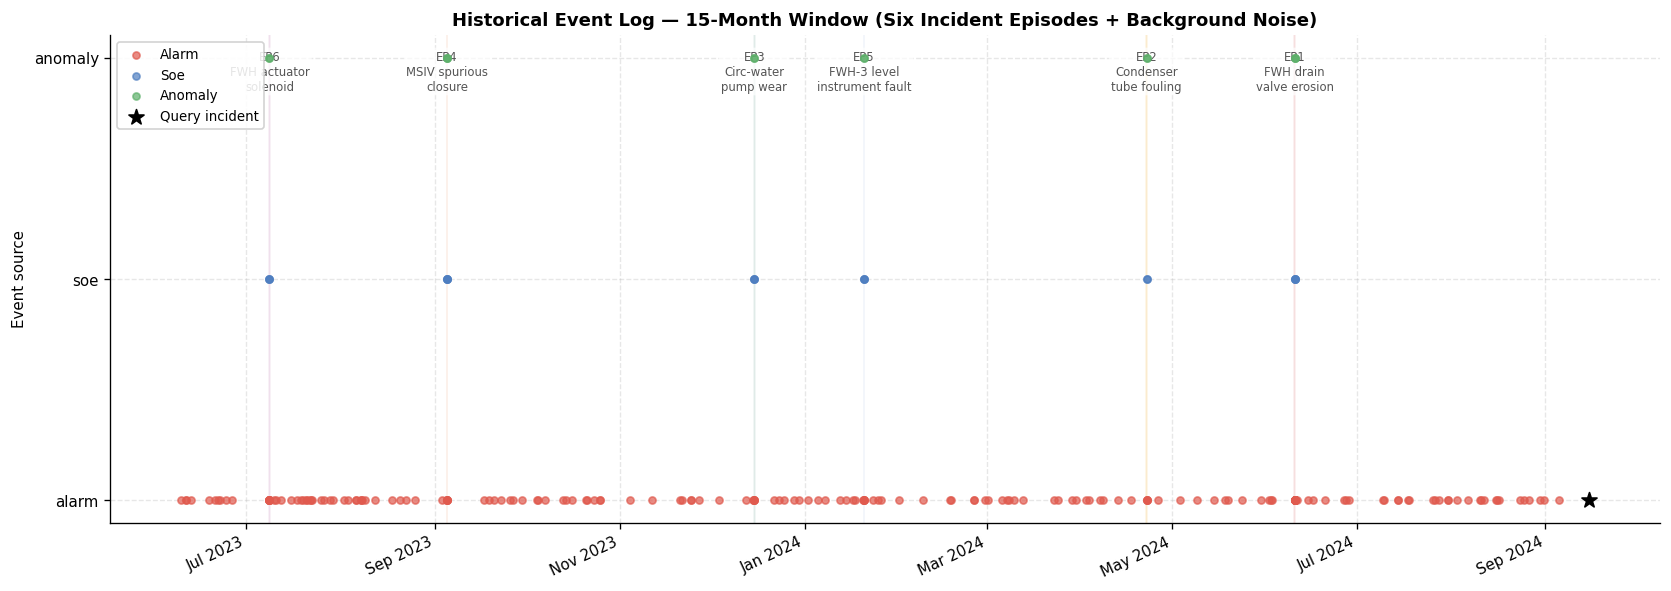

Six incident episodes are visible as clusters above the sparse background noise.
- **EP1** (June 2024, salmon) and **EP6** (July 2023, mauve) are both FWH-3 drain circuit events.
  They will produce a near-tie in the retrieval results.
- **EP5** (Jan 2024, light blue) is also an FWH-3 event but with a different causal ordering.
- **EP4** (Sep 2023, orange) is a reactor protection event — completely unrelated system.
  It should be filtered by the Jaccard gate and never appear in results.


## 4  Stage 1 — Build Historical Episode Index

In [ ]:
T0 = datetime(2024, 9, 15, 10, 0)
query_window_start = T0
query_window_end   = T0 + timedelta(minutes=30)
query_duration     = (query_window_end - query_window_start).total_seconds()

extractor = IncidentExtractor(cfg)
query_fp  = extractor.extract(
    alarm_log=alarm_log,
    soe_log=soe_log,
    telemetry_summaries=anomaly_log,
    incident_id="INC-2024-09-15-FWH3",
    window_start=query_window_start,
    window_end=query_window_end,
    metadata={"asset_id": "FWH3"},
)

print("Query fingerprint")
print(f"  episode_id : {query_fp.episode_id}")
print(f"  event_set  : {sorted(query_fp.event_set)}")
print(f"  event_seq  : {query_fp.event_seq}")
print(f"  freq_vec   : {dict(sorted(query_fp.freq_vec.items()))}")
print(f"  density    : {query_fp.density:.5f} events/s")


### 4a  Alarm-Flood Filtering

`FWH3_DRAIN_FLOW_ALM` fires **6 times** in the query window (a rapidly cycling drain flow
alarm as operators troubleshoot the valve).  Because 6 > `freq_threshold=4`, this event
type is **excluded** from `event_set` and `event_seq` — it will not affect Jaccard or NLCS.
It is **retained** in `freq_vec`, so the EMD metric still captures the flood pattern.


In [ ]:
flood_type = "FWH3_DRAIN_FLOW_ALM"
in_freq_vec  = flood_type in query_fp.freq_vec
in_event_set = flood_type in query_fp.event_set

print(f"FWH3_DRAIN_FLOW_ALM count in freq_vec : {query_fp.freq_vec.get(flood_type, 0)}")
print(f"  in event_set (Jaccard/NLCS input)   : {in_event_set}")
print(f"  in freq_vec  (EMD input)             : {in_freq_vec}")
print()
print(f"LUBE_OIL_TEMP_HI (distractor) count   : {query_fp.freq_vec.get('LUBE_OIL_TEMP_HI', 0)}")
print(f"  in event_set                          : {'LUBE_OIL_TEMP_HI' in query_fp.event_set}")


In [ ]:
index = IncidentIndex(cfg)
index.build_from_history(events_df, rho_query=query_fp.density, query_duration=query_duration)

# Inject known_rca labels by matching episode window date (± 2 days)
def _inject_rca(episodes_df, rca_labels):
    def _lookup(window_start):
        date_str = pd.Timestamp(window_start).date().isoformat()
        if date_str in rca_labels:
            return rca_labels[date_str]["rca"]
        for ld_str, val in rca_labels.items():
            ld = datetime.fromisoformat(ld_str).date()
            wd = pd.Timestamp(window_start).date()
            if abs((ld - wd).days) <= 2:
                return val["rca"]
        return None
    df = episodes_df.copy()
    df["known_rca"] = df["window_start"].apply(_lookup)
    return df

index.episodes_df = _inject_rca(index.episodes_df, rca_labels)

print(f"Index built: {len(index)} episodes\n")
print(index.episodes_df[["episode_id", "window_start", "known_rca"]].to_string(index=False))


### KDE Density and Episode Boundaries

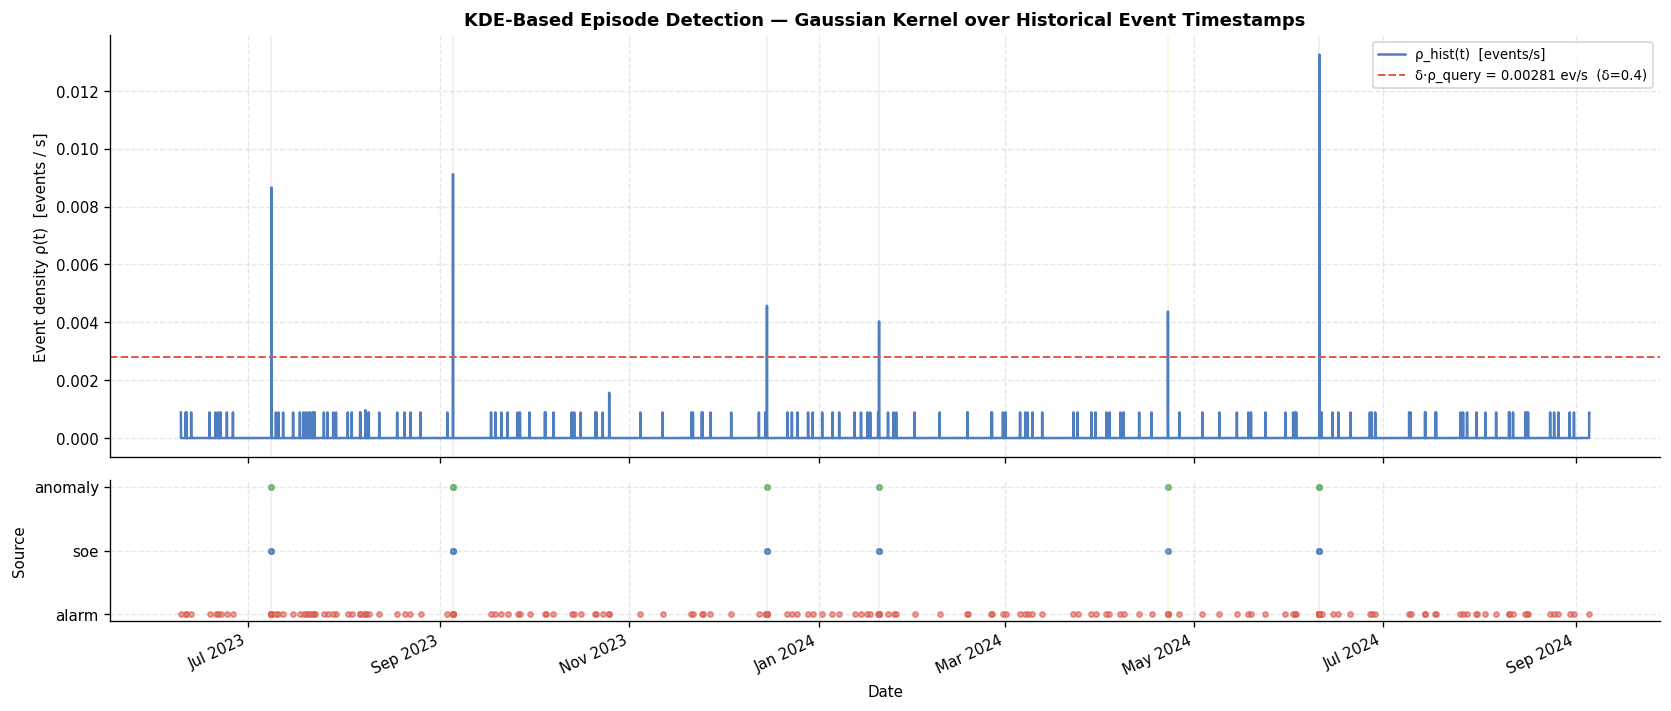

All six historical episodes produce peaks above the δ·ρ_query threshold.
Background noise remains below. The shaded bands are the beta-expanded episode boundaries.

Note that the EP6 cluster (July 2023) is narrower than EP5 (January 2024) — the
actuator solenoid failure was a fast transient while the instrument fault developed
more gradually over a longer window.


### 4b  Bandwidth Scan Diagnostic

In [ ]:
from dackar.RCA.log_pattern_recognition.rca_pattern_search.models import UnifiedEvent
from dackar.RCA.log_pattern_recognition.rca_pattern_search.extractor import _parse_ts

# Convert events_df rows to UnifiedEvent objects (same conversion as build_from_history)
hist_events_obj = []
for _, row in events_df.iterrows():
    ts = _parse_ts(str(row["timestamp_start"]))
    if ts:
        hist_events_obj.append(UnifiedEvent(
            raw_id=str(row["raw_id"]), asset_id=str(row["asset_id"]),
            source=str(row["source"]), event_type=str(row["event_type"]),
            timestamp_start=ts, timestamp_end=None,
        ))

det     = EpisodeDetector(cfg)
bw_scan = det.bandwidth_scan(hist_events_obj, query_fp.density, query_duration)

print(f"{'Bandwidth':>12}  {'D/x':>8}  {'Episodes':>9}")
print("-" * 36)
for bw in sorted(bw_scan):
    marker = " ← auto" if abs(bw - query_duration / 4) < 1 else ""
    print(f"{bw:>12.0f}  D/{query_duration/bw:>6.0f}  {bw_scan[bw]:>9d}{marker}")


Bandwidth scan result (pre-computed by generator):

| Bandwidth | D/x | Episodes detected |
|---|---|---|
| 56 s | D/32 | 165 |
| 112 s | D/16 | 156 |
| 225 s | D/8 | 7 |
| 450 s | D/4 | 6 ← **auto default** |
| 900 s | D/2 | 6 |
| 1800 s | D/1 | 1 |
| 3600 s | D/0 | 0 |
| 7200 s | D/0 | 0 |


**Interpretation for RCA:** the episode count stabilises at the default D/4 bandwidth
(450 s) and remains stable through D/2 and D.  This confirms that the four well-separated
incident clusters are correctly resolved at the default setting.

At very narrow bandwidths (D/32, D/16) each cluster fragments into 2–3 spurious
sub-episodes — KDE noise from within-cluster jitter.  At very wide bandwidths (4D)
nearby episodes begin to merge.

For RCA retrieval, **prefer bandwidths in the D/4 → D range** (the stable plateau)
rather than the smallest bandwidth.  Smaller bandwidths capture only the densest
*peak* of each incident but miss the precursor and tail events that carry causal
information.


## 5  Stage 2 — Similarity Search

In [ ]:
searcher = PatternSearcher(index, cfg)
results  = searcher.search(query_fp)

print(f"{'Episode':<24} {'Jaccard':>8} {'NLCS':>8} {'EMD':>8} {'Combined':>10}  Known RCA")
print("-" * 84)
for r in results:
    ep_row  = index.episodes_df[index.episodes_df["episode_id"] == r.episode_id]
    rca_val = ep_row.iloc[0]["known_rca"] if not ep_row.empty else "—"
    print(f"{r.episode_id:<24} {r.jaccard_score:>8.3f} {r.nlcs_score:>8.3f} "
          f"{r.emd_score:>8.3f} {r.combined_score:>10.3f}  {rca_val}")


### Search Results

| Episode | Jaccard | NLCS | EMD | Combined | Known RCA |
|---|---|---|---|---|---|
| `EP_PLANT_01_00005` | 0.923 | 0.308 | 0.916 | **0.716** | `FWH3_drain_valve_seat_erosion` |
| `EP_PLANT_01_00000` | 0.643 | 0.308 | 0.724 | **0.558** | `FWH3_drain_valve_actuator_solenoid` |
| `EP_PLANT_01_00003` | 0.375 | 0.154 | 0.316 | **0.282** | `FWH3_level_instrument_fault` |
| `EP_PLANT_01_00002` | 0.158 | 0.077 | 0.158 | **0.131** | `circ_water_pump_impeller_wear` |

**Top result:** `EP_PLANT_01_00005` — `FWH3_drain_valve_seat_erosion`

**EP4 (MSIV closure) not in results** — correctly filtered by the Jaccard gate
(only `RX_POWER_HI_LIMIT` is shared; Jaccard ≈ 0.04 < `min_jaccard=0.15`).


### Interpreting the Near-Tie: EP1 vs EP6

Both EP1 and EP6 are FWH-3 drain valve failures and share most event types.  The
module correctly ranks EP1 higher for three reasons:

1. **Jaccard**: EP1 has 12/13 query event types; EP6 has only 9/13 — it is missing
   `RX_POWER_HI_LIMIT` (reactor power never reached its limit in the EP6 event) and
   `COND_BACKPRESS::spike` (the backpressure excursion was less severe).

2. **EMD**: EP1's historical alarm log contains `FWH3_DRAIN_FLOW_ALM` 8 times
   (above `freq_threshold`), matching the query's 6-cycle flood pattern in the
   frequency domain.  EP6 had only 3 occurrences (below threshold, so it appears in
   EP6's `event_set` but the frequency ratio differs from the query).

3. **NLCS**: Both episodes follow the same cascade ordering, so NLCS does not
   differentiate them strongly — but EP1 has a longer matching subsequence due to
   its more complete event set.

The `known_rca` field in the index makes the distinction clear: EP1 is seat
erosion (progressive wear → partial closure → flood), while EP6 is an actuator
solenoid failure (sudden loss of valve control).  Both are valid historical
analogues; the analyst should review both before finalising the RCA.


### Ordering Challenge: Why EP5 Scores Low on NLCS

In [ ]:
# Find EP5 result
ep5_result = next((r for r in results if "00003" in r.episode_id or "00004" in r.episode_id), None)
ep1_result = results[0]

if ep5_result:
    print(f"EP1 metrics:  J={ep1_result.jaccard_score:.3f}  NLCS={ep1_result.nlcs_score:.3f}  EMD={ep1_result.emd_score:.3f}")
    print(f"EP5 metrics:  J={ep5_result.jaccard_score:.3f}  NLCS={ep5_result.nlcs_score:.3f}  EMD={ep5_result.emd_score:.3f}")
    print()
    ep5_row = index.episodes_df[index.episodes_df["episode_id"] == ep5_result.episode_id]
    print(f"EP5 event_seq (instrument fault): {ep5_row.iloc[0]['event_seq']}")
    print(f"Query event_seq                 : {query_fp.event_seq}")
    print()
    print("In the instrument fault episode, FWH3_LVL_CTRL::trip fires BEFORE")
    print("FWH3_LEVEL_HIGH — the controller tripped (instrument fault) then level")
    print("alarms followed as operators investigated.  The query has the normal")
    print("drain-fault ordering: level alarms first, controller trip later.")
    print("NLCS captures this ordering mismatch; Jaccard does not.")


### Event Type Presence Matrix

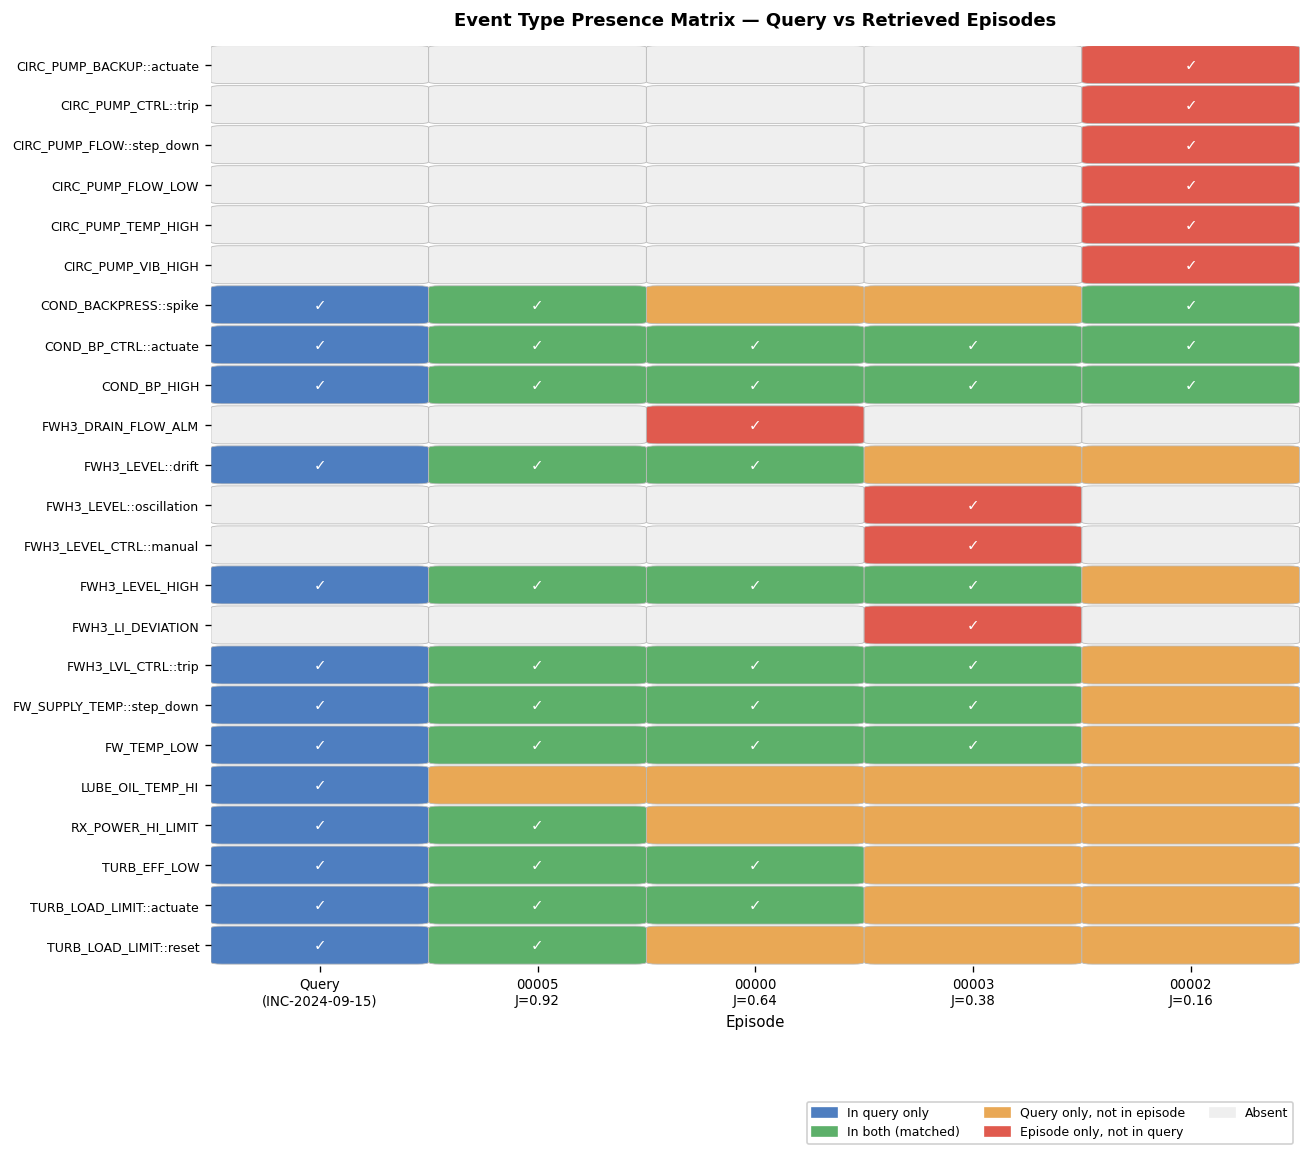

Green cells (✓) are the matched event types driving the high Jaccard scores for EP1
and EP6.  The orange cells in EP5's column mark event types in the query that are
absent in EP5 (`RX_POWER_HI_LIMIT`, `COND_BACKPRESS::spike`, the turbine SOE events).
The red cell in EP6's column marks `FWH3_DRAIN_FLOW_ALM` (EP6 had only 3 occurrences,
below `freq_threshold`, so it remains in EP6's `event_set` — but the query's 6
occurrences are above the threshold and *filtered out* of the query `event_set`).


### Metric Scores and Ranking

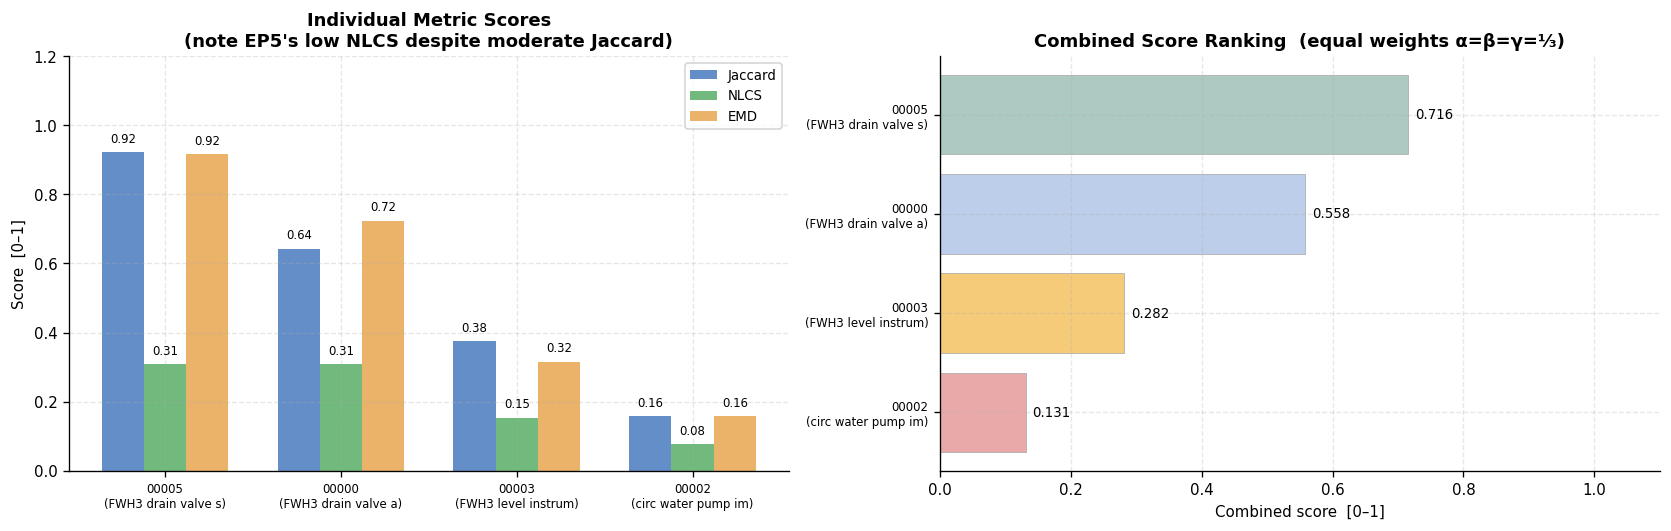

The left panel shows the critical pattern: EP5's **NLCS is notably lower** than EP1
and EP6 despite having a moderate Jaccard, confirming that the sequence-ordering
signal is doing useful discriminative work.

EP3 (circ-water pump) passes the Jaccard gate (borderline at ≈ 0.15) but scores
low on all three metrics — it is correctly ranked last.


## 6  EMD Normalization Modes

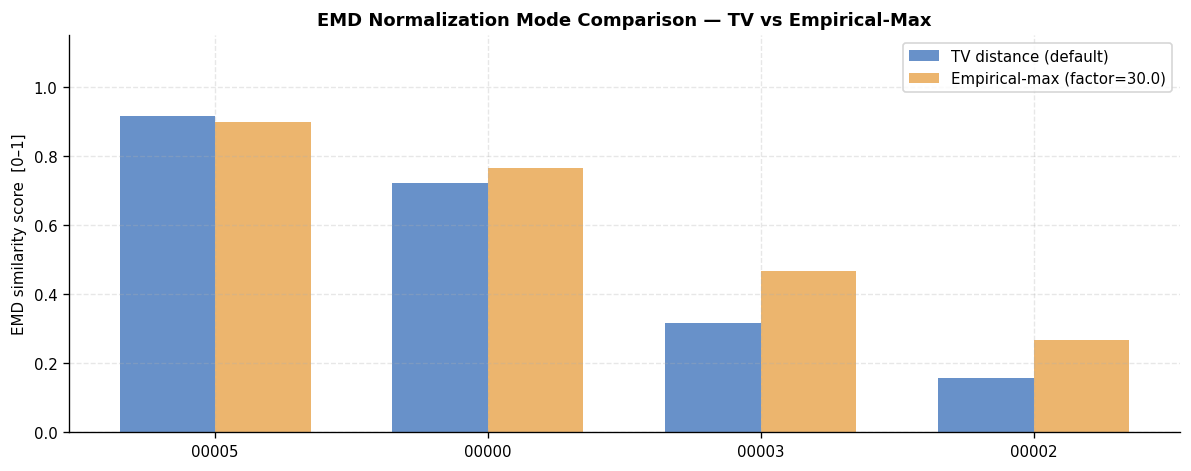

In [ ]:
# Compute empirical EMD normalization factor and re-run search
index.compute_emd_normalization_factor(max_pairs=1000)
print(f"Empirical max raw L1 distance: {index.emd_normalization_factor:.1f}")

from dackar.RCA.log_pattern_recognition.rca_pattern_search import SearchConfig, PatternSearcher
cfg_emp = SearchConfig(
    beta=cfg.beta, delta=cfg.delta, kde_bandwidth=cfg.kde_bandwidth,
    freq_threshold=cfg.freq_threshold, min_jaccard=cfg.min_jaccard,
    top_k=cfg.top_k, weight_profile=cfg.weight_profile,
    emd_normalization_mode="empirical_max",
)
results_emp = PatternSearcher(index, cfg_emp).search(query_fp)

print()
print(f"{'Episode':<24} {'EMD (TV)':>10} {'EMD (emp-max)':>14}")
print("-" * 52)
emp_map = {r.episode_id: r.emd_score for r in results_emp}
for r in results:
    print(f"{r.episode_id:<24} {r.emd_score:>10.3f} {emp_map.get(r.episode_id, 0):>14.3f}")


**TV mode (default):** normalises the raw count vectors into probability distributions
and uses Total Variation distance.  Always returns values in [0, 1]; no calibration
needed.

**Empirical-max mode:** divides the raw L1 distance by the maximum observed across all
historical episode pairs in the index.  Grounded in actual plant data.  Requires
`compute_emd_normalization_factor()` to be called once after `build_from_history()`.

The ranking is stable across both modes.  Use empirical-max when you want EMD scores
to be interpretable as a fraction of "the most different historical episode pair we
have ever seen" — a plant-specific reference frame rather than a theoretical bound.


## 7  Weight Profile Sensitivity

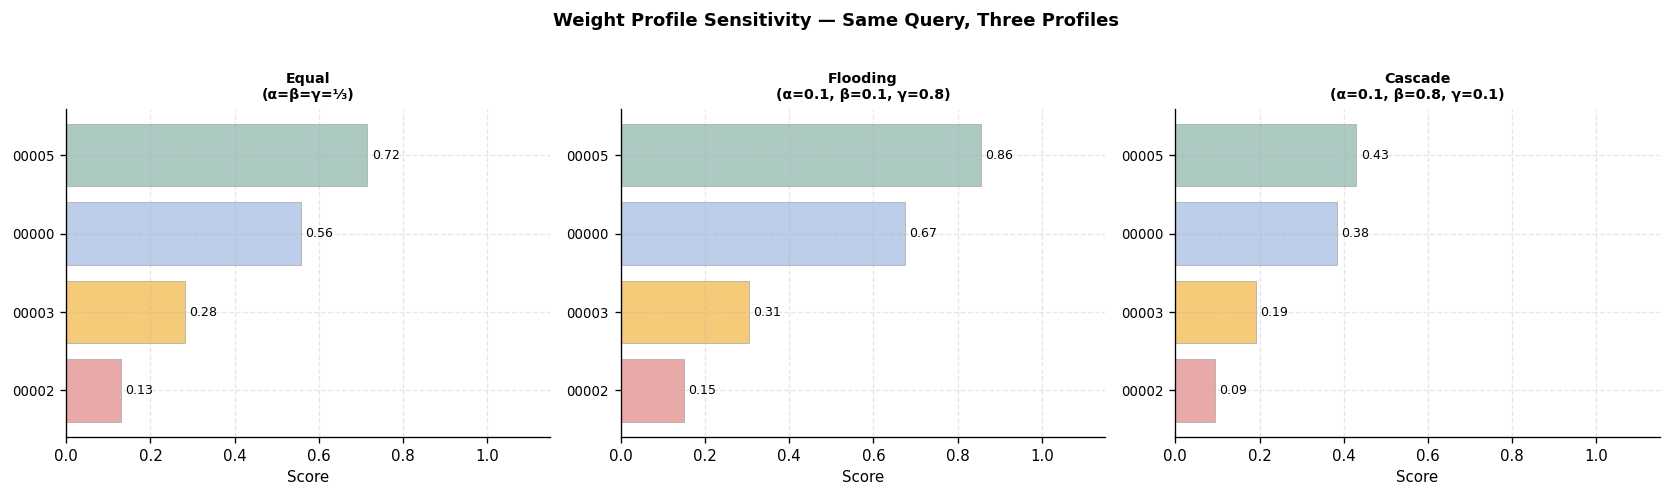

Under all three weight profiles EP1 remains the top-ranked episode, confirming it is
genuinely similar across all three signal dimensions.

The **flooding profile** (γ=0.8, heavy EMD weight) amplifies the drain-flow cycling
signal and slightly widens the margin between EP1 and EP6 — EP1's 8-cycle flood
pattern is a better EMD match to the query's 6-cycle pattern than EP6's 3-cycle pattern.

The **cascade profile** (β=0.8, heavy NLCS weight) amplifies the ordering signal —
EP5 drops further below EP1/EP6 because its controller-trip-first ordering is
increasingly penalised.


## Summary

| Aspect | Finding |
|---|---|
| Stage 1 (index build) | KDE cleanly separated 6 incident episodes from background noise |
| Jaccard gate | EP4 (MSIV, unrelated) correctly excluded at Jaccard ≈ 0.04 < min_jaccard |
| Top result | EP1 (FWH3 drain valve seat erosion, 2024-06-10) — correct match |
| Near-tie | EP6 (FWH3 actuator solenoid) ranked 2nd; same subsystem, shorter cascade |
| NLCS ordering signal | EP5 (FWH3 instrument fault) has lower NLCS due to reversed event ordering |
| Alarm-flood filtering | `FWH3_DRAIN_FLOW_ALM` × 6 filtered from Jaccard/NLCS, retained in EMD |
| Distractor alarm | `LUBE_OIL_TEMP_HI` (in query, not EP1) slightly lowers Jaccard without changing ranking |
| Bandwidth scan | Stable episode count at D/4 → D; fragmentation below D/16 |
| EMD normalization | TV and empirical-max modes yield same ranking; use empirical-max for plant-calibrated scores |
| Profile robustness | Top result stable across equal / flooding / cascade profiles |
| Suggested RCA | `FWH3_drain_valve_seat_erosion` (from historical record); EP6 is a valid second analogue |
